In [76]:
# buildling more intuition around the activations now
# starting off with code from prev lecture but cleaned up

In [145]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [146]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [147]:
len(words)

32033

In [148]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [211]:
# MLP revisited
# init model
n_embd = 10  # the dimensionality of the character embedding vectors
n_hidden = 200  # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C = torch.randn((vocab_size, n_embd), generator=g)

# W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.02 # See (2), superseded by (3)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size) ** 0.5) # See (3)
# (4): no b1 bc of batch norm bias
# b1 = torch.randn(n_hidden, generator=g) * 0.01 # See (2)

W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 # (1): we make logits very small by multiplying by 0.01
b2 = torch.randn(vocab_size, generator=g) * 0 # (1): Added *0 to ensure that logits are roughly 0

# Batch norm gain + bias see (4)
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

# Calibrated batch norm mean, std for deploy time
# not part of parameters
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1,  W2, b2, bngain, bnbias] # (4): no b1 bc of batch norm bias
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
      p.requires_grad = True

12097


In [205]:
# :::(4):::
print(hpreact.shape)
print(hpreact.mean(0, keepdim=True).shape) # mean over all the elements in bach
print(hpreact.std(0, keepdim=True).shape)

torch.Size([32, 200])
torch.Size([1, 200])
torch.Size([1, 200])


In [216]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y
    
    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors
    
    # hidden layer pre-activation
    hpreact = embcat @ W1 + b1
    # START Batch norm --------
    bnmeani = hpreact.mean(0, keepdims=True)
    bnstdi = hpreact.std(0, keepdims=True)
    hpreact = bngain * ((hpreact - bnmeani) / bnstdi) + bnbias # See (4)

    with torch.no_grad():
        # values are mostly old values but partially from new values
        # The values (0.999 and 0.001) here are called "momentum" in torch's bachnorm (default 0.1 in torch)
        # For large batch size we get roughly the same result for these across batches so we can use higher momentum
        # Our batch is 32 so we need a smaller momentum so it doesn't thrash too much
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # END Batch norm --------
    
    # hidden layer activations
    h = torch.tanh(hpreact)
    
    # output layer
    logits = h @ W2 + b2  
    loss = F.cross_entropy(logits, Yb)  # loss function
    
    # backward pass
    for p in parameters:
      p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
      p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:  # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


      0/ 200000: 1.8981
  10000/ 200000: 2.2204
  20000/ 200000: 2.3162
  30000/ 200000: 2.4122
  40000/ 200000: 2.2068
  50000/ 200000: 1.9309
  60000/ 200000: 2.1601
  70000/ 200000: 2.5136
  80000/ 200000: 1.9833
  90000/ 200000: 1.7697
 100000/ 200000: 1.9102
 110000/ 200000: 2.5948
 120000/ 200000: 1.6488
 130000/ 200000: 2.0022
 140000/ 200000: 2.4041
 150000/ 200000: 2.2843
 160000/ 200000: 2.4986
 170000/ 200000: 1.8307
 180000/ 200000: 1.9674
 190000/ 200000: 2.1390


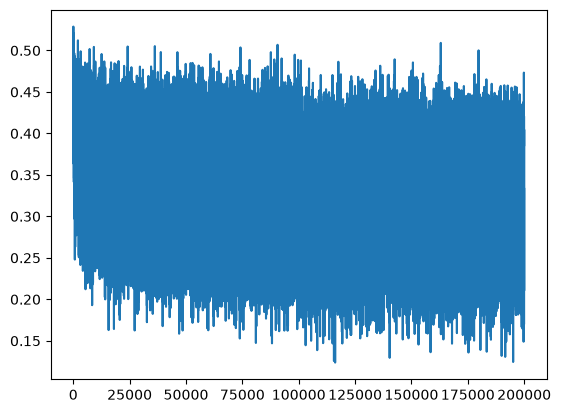

In [207]:
plt.plot(lossi)

In [208]:
# See (4)
# Calibrate BatchNorm at the end of training 
# This is calculating after training, but we can do it while training too. See above

with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)
# print(bnmean, '\n', bnmean_running, '\n',  bnstd, '\n', bnstd_running) # means, stds roughly equal

In [210]:
@torch.no_grad()  # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
      'train': (Xtr, Ytr),
      'val': (Xdev, Ydev),
      'test': (Xte, Yte),
    }[split]
    
    emb = C[x]  # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)  # concat into (N, block_size * n_embd)

    # h = torch.tanh(embcat @ W1 + b1)  # (N, n_hidden)
    # See (4): need to do batch norm during eval time too
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * ((hpreact - hpreact.mean(0, keepdims=True)) / hpreact.std(0, keepdims=True)) + bnbias # See (4)
    # Actually, we want to use calibrated values
    # hpreact = bngain * ((hpreact - bnmean) / bnstd) + bnbias # See (4)
    # Actually, we want to use running calibrated values
    hpreact = bngain * ((hpreact - bnmean_running) / bnstd_running) + bnbias # See (4)
    h = torch.tanh(hpreact)  # hidden layer
    
    logits = h @ W2 + b2  # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066591501235962
val 2.1050572395324707


In [175]:
'''
# loss log

### copied this part V
# original:
train 2.1245384216308594
val   2.168196439743042

# fix softmax confidently wrong:
train 2.07
val   2.13

# fix tanh layer too saturated at init:
train 2.0355966091156006
val   2.1026785373687744

# use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693
val   2.168196439743042

# add a batch norm layer
train 2.0668270587921143
val 2.104844808578491
### copied this part ^

# calibrated batch norm
train 2.0668270587921143
val 2.104926824569702
'''

'\n# loss log\n\n### copied this part V\n# original:\ntrain 2.1245384216308594\nval   2.168196439743042\n\n# fix softmax confidently wrong:\ntrain 2.07\nval   2.13\n\n# fix tanh layer too saturated at init:\ntrain 2.0355966091156006\nval   2.1026785373687744\n\n# use semi-principled "kaiming init" instead of hacky init:\ntrain 2.0376641750335693\nval   2.168196439743042\n\n# add a batch norm layer\ntrain 2.0668270587921143\nval 2.104844808578491\n### copied this part ^\n\n# calibrated batch norm\ntrain 2.0668270587921143\nval 2.104926824569702\n'

In [133]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context = [0] * block_size  # initialize with all '...'

  while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)

      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()

      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)

      # if we sample the special '.' token, break
      if ix == 0:
          break

  print(''.join(itos[i] for i in out))  # decode and print the generated word


carmahzaylyn.
kiffinleige.
tyrencessa.
jazon.
nadelynn.
jareei.
nellara.
chaiivan.
legyn.
ham.
joce.
quint.
salin.
alianni.
waveron.
jaryxin.
kaellissa.
med.
edi.
abette.


In [69]:
'''
:::(1):::
we observe above that the loss is 27. that's quite high so our initialization is bad
we expect a lower number: 
at initialization we don't expect to believe one char is more likely than another so we want a uniform likelyhood
i.e. 1/27 prob for any char
loss is negative log prob
i.e. 3.29
we want the logits to be roughly equal when we start training (normalization in softmax will make the distribution uniform)

We set the weights of second layer to be very small and biases as 0 so the logits are very small
Why not set to 0? We need some entropy for symmetry breaking (TODO).

With these optimizations, we notice that the hockeystick shape of the graph is no longer present because
we start at a much more reasonable loss
overall loss is also lower because we don't spend first iterations squashing down weights

'''
-torch.tensor(1/27).log() # expected initial loss

tensor(3.2958)

torch.Size([1, 200])


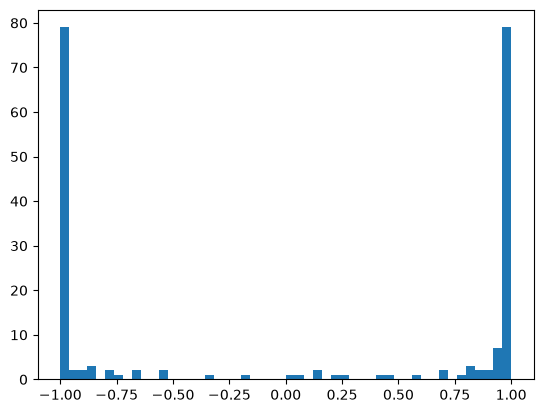

In [70]:
'''
:::(2):::
Still a deeper problem lurking in initialization
logits are ok, but hidden state activations (h) are weird
many elements are 1 or -1
tanh squashes the outputs as seen below
tanh is very "active"
'''
print(h.shape)
plt.hist(h.view(-1).tolist(), 50);

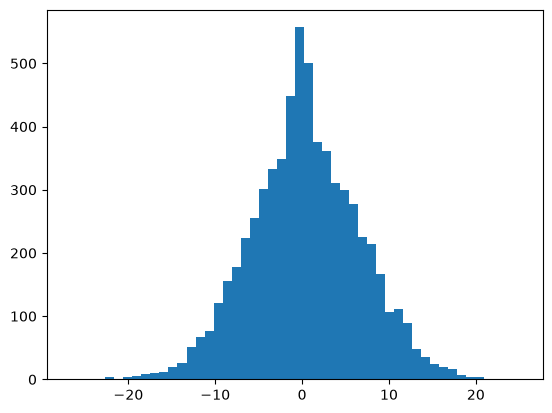

In [71]:
'''
(2) cont'd
we can look at preactivations and notice that the distribution is very broad so lots of numbers take on extreme values
might not look like an issue but this is not good

we kill the gradient because backprop on tanh is like this
  grad += (1 - x ** 2) * out.grad (from micrograd)
for x close to 1, -1 grad becomes 0 and out.grad just doesn't propagate

the weights and biases of this neuron won't affect the loss because it's in the flat portion of tanh
https://www.wolframalpha.com/input?i=tanh%28x%29+from+-10+to+10

if tanh output is 0, the output gradient just flows through 

'''
plt.hist(hpreact.view(-1).tolist(), 50);

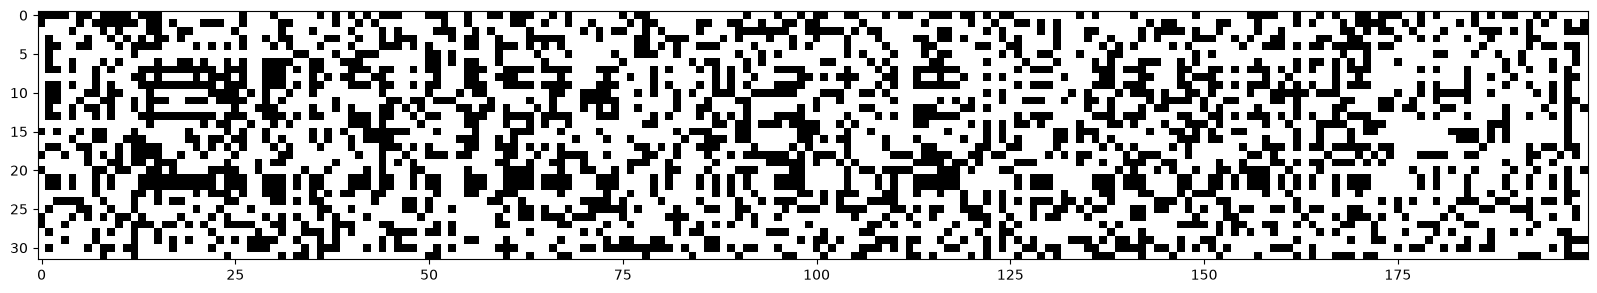

In [89]:
'''
(2) cont'd
for each 32 examples, we see 200 hidden neurons
we see a lot of white => lot of active tanh neurons that are in the flat tail 
  i.e. backward gradient destroyed

if any of the 200 neurons have the entire col white => dead neuron
  initialization of weights and biases could be such that no example activates it
  it will never learn aka dead neuron

we don't see any completely white columns

same will be true for other squashing activations like sigmoid, relu

dead neurons can happen at init but also during training if the learning rate is very high

how to fix?
we want hpreact to be close to 0 similar to (1)


----
from llm:
 h has shape:

  (batch size, number of hidden neurons)
  = (32, 200)

  So the plot is 2D because it turns that matrix into an image:

  - Each row = one training example from the 32-example minibatch.
  - Each column = one of the 200 hidden neurons.
  - Each pixel answers: “Was this neuron saturated for this example?”

  The plotted expression is:

  h.abs() > 0.99

  Since h = tanh(hpreact), values near -1 or +1 are in tanh’s flat/saturated region. There, its gradient is near zero, so learning through that neuron
  becomes difficult.

  checking whether too many activations are saturated. A few is fine; entire columns saturated across nearly every row indicate unhealthy
  initialization/training. The image has no spatial meaning—it is just a compact view of “examples × neurons.”
'''
# Run after training before sampling
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

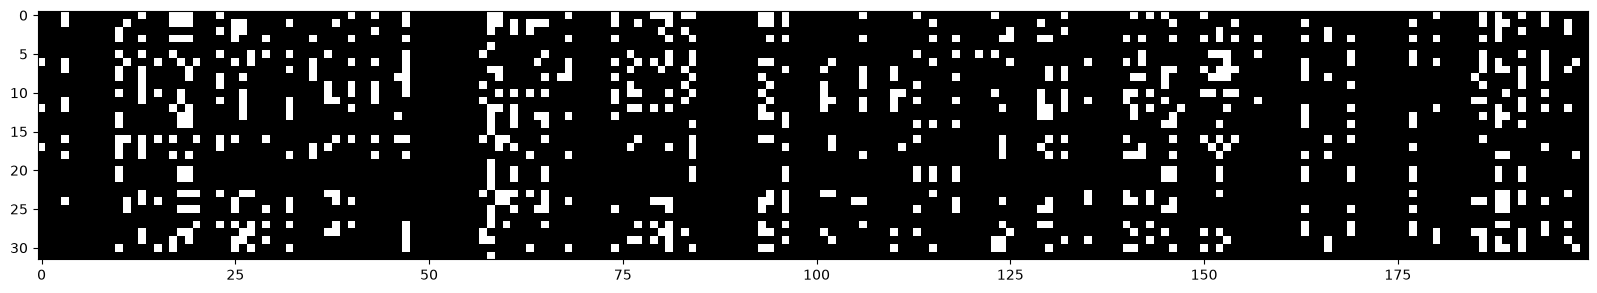

In [111]:
'''
(2) cont'd
we notice that there are few white cells here, also loss goes down because we have more productive iterations
'''

# Run after fix -- observe nearly no white cells
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

In [112]:
'''
overall, initialization has quite an impact on the performance
our network is very small so it still learns eventually
with deeper networks (eg 50 layers) things can get more complicated
these problems stack up and the network may not train at all if the initialization is bad

should be aware, scrutinize, plot!
'''

'\noverall, initialization has quite an impact on the performance\nour network is very small so it still learns eventually\nwith deeper networks (eg 50 layers) things can get more complicated\nthese problems stack up and the network may not train at all if the initialization is bad\n\nshould be aware, scrutinize, plot!\n'

In [134]:
'''
:::(3):::
we used a lot of magic numbers above (* 0.02, *0.01, etc)
hard to figure out how to set these for a large network
more principled approach: see above for intuition

many papers talk about this. in MLP we can have very deep networks and we need to ensure activations are well behaved
i.e. don't shrink to 0 or go to inf
Kaiming He paper: studies CNN with relu/prelu non linearity
process similar
relu tosses away negative numbers (https://www.wolframalpha.com/input/?i=relu%28x%29)
so we need to add a gain and the paper says W = W * sqrt(2/nl) where nl = fan in

Paper also talks about how to ensure that backwards pass needs to ensure that the activations are well behaved
they say if you init fwd pass correctly, backward pass is also approx well behaved

Kaiming init implemented in torch for us: https://docs.pytorch.org/docs/2.13/nn.init.html#torch.nn.init.kaiming_normal_
Most common way of initializing NNs

torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu', generator=None)
mode: what are we normalizing? activations or gaussians? -- most people just do default bc paper says it doens't matter too much

when paper was written, we needed to be much more careful of gains, init etc
was very finicky and fragile esp if NN is deep
modern innovations made things more well-behaved:
eg: residual connections, normalization layers (batch, layer, group), much better optimizers (instead of gradient descent rms prop and adam
Karpathy just does normalized weights by sqrt(nl); nl = fan in


after re-training the model, we have roughly the same loss but we arrive there in a much more principled manner
no magic numbers
'''

"\n:::(3):::\nwe used a lot of magic numbers above (* 0.02, *0.01, etc)\nhard to figure out how to set these for a large network\nmore principled approach: see above for intuition\n\nmany papers talk about this. in MLP we can have very deep networks and we need to ensure activations are well behaved\ni.e. don't shrink to 0 or go to inf\nKaiming He paper: studies CNN with relu/prelu non linearity\nprocess similar\nrelu tosses away negative numbers (https://www.wolframalpha.com/input/?i=relu%28x%29)\nso we need to add a gain and the paper says W = W * sqrt(2/nl) where nl = fan in\n\nPaper also talks about how to ensure that backwards pass needs to ensure that the activations are well behaved\nthey say if you init fwd pass correctly, backward pass is also approx well behaved\n\nKaiming init implemented in torch for us: https://docs.pytorch.org/docs/2.13/nn.init.html#torch.nn.init.kaiming_normal_\nMost common way of initializing NNs\n\ntorch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_i

tensor(0.0018) tensor(0.9943)
tensor(0.0002) tensor(0.9853)
0.3042903097250923


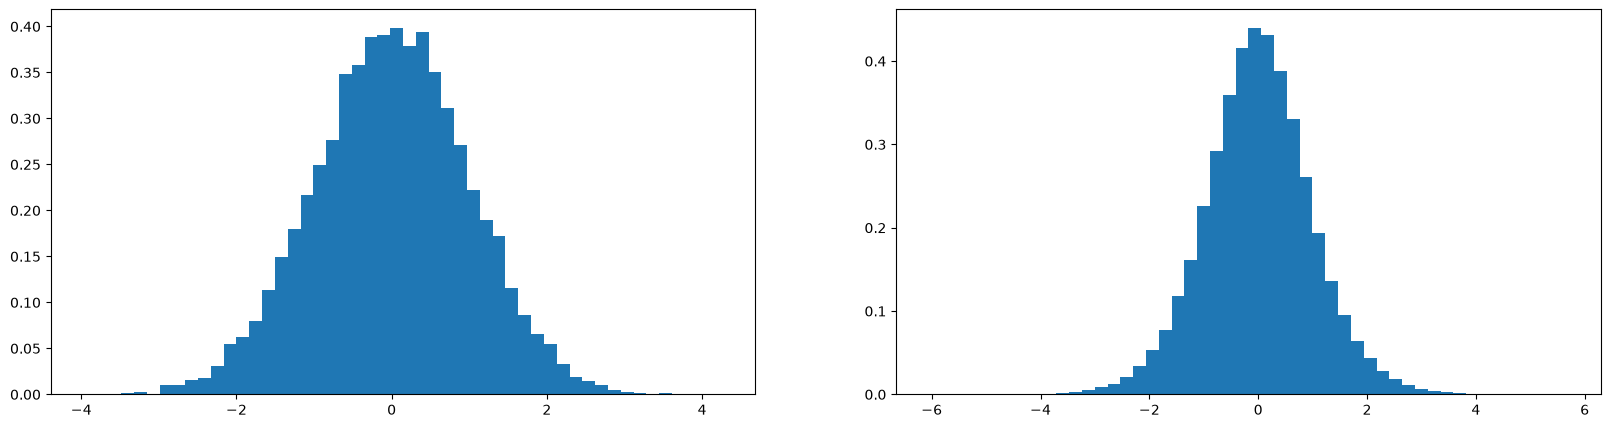

In [136]:
## :::(3):::
'''
standard deviation of x expands when you multiply by w
We want things to have simillar activation. why? 

---
from llm:

  If layer 1 has activations with a reasonable scale, but layer 2 suddenly has activations 10× larger or 100× smaller, the network becomes hard to
  train:

  - Too large: tanh saturates at -1 or +1, so its gradient is near zero.
  - Too small: the signal becomes weak and can gradually disappear through layers.
  - In both cases, gradients during backprop can vanish or explode.

  Keeping similar activation statistics from layer to layer means the network preserves a healthy signal scale as it goes forward—and a healthy
  gradient scale as it goes backward.

---

if we increase w, the gaussian y gets larger and opposite
what do we multiply W by to preserve unit std dev?
mathematically, we are supposed to divide by the sqrt of fan in
fan in is number of input elements (10)


'''

def tmp():
    x = torch.randn(1000, 10)
    w = torch.randn(10, 200) / 10 **0.5
    y = x @ w
    
    print(x.mean(), x.std())
    print(y.mean(), y.std())
    
    plt.figure(figsize=(20, 5))
    plt.subplot(121)
    plt.hist(x.view(-1).tolist(), 50, density=True);
    
    plt.subplot(122)
    plt.hist(y.view(-1).tolist(), 50, density=True);
tmp()

# For our model
# 5/3 is gain for tanh
# fan in is 30
print( (5/3) / 30 ** 0.5) # 0.3042903097250923
# so we mult by ~0.3 
    

In [215]:
'''
:::(4):::

batch normalization
2015 paper

hpreact -> hidden layer's preactivation 
as discussed prev, we don't want it to be too small/large bc of tanh 
want them to be roughly gaussian at init
batch norm paper insight:
just normalize hidden state to be gaussian
something like this: (see above)
  mean = hpreact.mean(0, keepdim=True)
  std = hpreact.std(0, keepdim=True)

  hpreact_normalized = (hpreact - mean) / (std + epsilon) # epsilon to prevent div by 0

All of this^ is differntiable so we can train on it

We only want to do this on initialization, not during training so we have to do "scale and shift" as described in the paper
add a batch norm gain and bias 
bngain, bnbias are both parameters of the model and will be trained
tbh this kinda feels like magic right now. need to look into this some more.

new loss is similar to old but this is bc our NN is small
typically BatchNorm is put in many layers and it stabilizes trainig

Stability comes at a cost though:
"strange and unnatural"
before BatchNorm, each batch was processed individually but now we couple the examples in the batch mathematically
now, the logits are a function of all the examples in that batch 
the logits of one example have jitter from other examples in the batch
but in a strange way this is desirable because this is a regularizer
the other examples are introducing entropy to one example's logits
the entropy makes it hard for the NN to overfit! :o

but even then, people don't like that the examples in the batch are couples mathematically (sometimes strange results/bugs)
but bc BatchNorm is a regularizer, it makes it harder to remove from the NN
alternatives are other norm techniques: linear norm, instance norm, group norm

BatchNorm was first normalization layer to be introduced
stabilized training

when we deploy the NN, we pass a single example to get an output, but now our NN estimates stats of a batch and expects batches
BatchNorm paper says
add a step after training that sets batchnorm mean, std over an entire set aka calibrate batchnorm statistics

but actually, we don't want to calculate bnmean, bnstd after training
paper says we can estimate these in a running manner during training


hpreact = embcat @ W + b1
b1 biases are meaningless bc we calculate mean and subtracting it so bias gets subtracted
b1.grad will be 0
Weight layers before batch norm should not use bias

Summary: BatchNorm used to control activations across NN. Tyically sprinkled in after multiplication layers (eg linear, convolution)
BatchNorm has params for gain, bias trained using backprop
2 buffers: meaning, std not trained using backprop but using the running mean update. used at inference
'''

'\n:::(4):::\n\nbatch normalization\n2015 paper\n\nhpreact -> hidden layer\'s preactivation \nas discussed prev, we don\'t want it to be too small/large bc of tanh \nwant them to be roughly gaussian at init\nbatch norm paper insight:\njust normalize hidden state to be gaussian\nsomething like this: (see above)\n  mean = hpreact.mean(0, keepdim=True)\n  std = hpreact.std(0, keepdim=True)\n\n  hpreact_normalized = (hpreact - mean) / (std + epsilon) # epsilon to prevent div by 0\n\nAll of this^ is differntiable so we can train on it\n\nWe only want to do this on initialization, not during training so we have to do "scale and shift" as described in the paper\nadd a batch norm gain and bias \nbngain, bnbias are both parameters of the model and will be trained\ntbh this kinda feels like magic right now. need to look into this some more.\n\nnew loss is similar to old but this is bc our NN is small\ntypically BatchNorm is put in many layers and it stabilizes trainig\n\nStability comes at a cos

In [276]:
# -------- Creating an API similar to PyTorch --------

g = torch.Generator().manual_seed(2147483647)  # for reproducibility

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weights = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weights
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weights] + ([self.bias] if self.bias is not None else [])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
    
        self.gain = torch.ones((1, dim))
        self.bias = torch.zeros((1, dim))
        
        # buffers
        self.mean_running = torch.zeros((1, dim))
        self.var_running = torch.ones((1, dim))

    def __call__(self, x):
        mean = x.mean(0, keepdims=True) if self.training else self.mean_running
        var = x.var(0, keepdims=True) if self.training else self.var_running

        self.out = self.gain * ((x - mean) / torch.sqrt(var + self.eps)) + self.bias

        if self.training:
            with torch.no_grad():
                self.mean_running = (1-self.momentum) * self.mean_running + self.momentum * mean
                self.var_running = (1-self.momentum) * self.var_running + self.momentum * var
        return self.out

    def parameters(self):
        return [self.gain, self.bias]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

# Some init stuff
with torch.no_grad():
    # last layer: make less confident
    layers[-1].gain *= 0.1
    # layers[-1].weights *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weights *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


47024


In [277]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y
    
    # forward pass
    emb = C[Xb]  # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1)  # concatenate the vectors

    out = embcat
    for layer in layers:
        out = layer(out)
    loss = F.cross_entropy(out, Yb)

    for p in parameters:
      p.grad = None
    loss.backward()
    
    # update
    lr = 0.1 if i < 100000 else 0.01  # step learning rate decay
    for p in parameters:
      p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:  # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    
    if i >= 1000:
        break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1043
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2266
  60000/ 200000: 1.7339
  70000/ 200000: 2.1748
  80000/ 200000: 2.1895
  90000/ 200000: 1.8281
 100000/ 200000: 2.3635
 110000/ 200000: 2.2015
 120000/ 200000: 2.1032
 130000/ 200000: 1.8564
 140000/ 200000: 1.8050
 150000/ 200000: 1.9258
 160000/ 200000: 1.8762
 170000/ 200000: 1.8334
 180000/ 200000: 2.2314
 190000/ 200000: 2.0513


In [275]:
# sample from the model

# BatchNorm must use its running statistics at inference time
for layer in layers:
  if isinstance(layer, BatchNorm1d):
      layer.training = False

g = torch.Generator().manual_seed(2147483647 + 10)

with torch.no_grad():
  for _ in range(20):

      out = []
      context = [0] * block_size  # initialize with all '...'

      while True:
          # forward pass the neural net
          emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
          x = emb.view(1, -1)

          for layer in layers:
              x = layer(x)

          probs = F.softmax(x, dim=1)

          # sample from the distribution
          ix = torch.multinomial(probs, num_samples=1, generator=g).item()

          # shift context window and track samples
          context = context[1:] + [ix]
          out.append(ix)

          # stop at '.'
          if ix == 0:
              break

      print(''.join(itos[i] for i in out))


carlah.
amelle.
khyriri.
reity.
skanya.
eja.
hube.
deliah.
jareei.
nellara.
chaiir.
kaleigh.
ham.
joce.
quintis.
lilah.
jadiquinte.
madiaryn.
kai.
eupitraylen.


layer 2 (      Tanh): mean -0.01, std 0.69, saturated: 14.03%
layer 5 (      Tanh): mean -0.02, std 0.72, saturated: 16.91%
layer 8 (      Tanh): mean -0.00, std 0.75, saturated: 15.75%
layer 11 (      Tanh): mean +0.02, std 0.77, saturated: 16.78%
layer 14 (      Tanh): mean -0.02, std 0.79, saturated: 18.72%


/var/folders/cy/yrd7js4122q74sd11189gwp40000gn/T/ipykernel_39541/1397477801.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

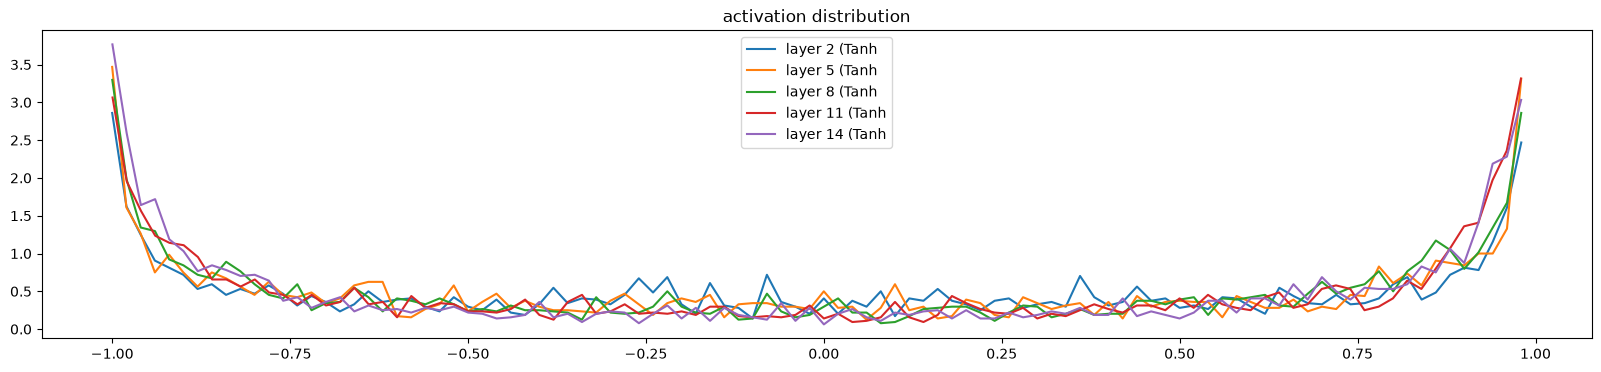

In [278]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')